In [1]:
from glob import glob
import sys
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from astrometry.util.fits import fits_table, merge_tables

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('py_files'), '..')))
from py_files import brick_DCR
# forced = fits.open('/pscratch/sd/n/nelfalou/fw-test/forced-brickwise-0292p045.fits')[1].data

In [2]:
# fns = glob('/pscratch/sd/n/nelfalou/legacypm-catalogue/020/forced-*.fits') + glob('/pscratch/sd/n/nelfalou/legacypm-catalogue/040/forced-*.fits') + glob('/pscratch/sd/n/nelfalou/legacypm-catalogue/050/forced-*.fits')
# fns.sort()
# len(fns)

In [3]:
FF, TT = [], []
degrees = ['190']

for deg in degrees:
    print(deg)
    fns = glob(f'/pscratch/sd/n/nelfalou/legacypm-catalogue/{ deg }/forced-*.fits')
    fns.sort()
    for fn in fns:
        try:
            forced = fits_table(fn)
        except:
            print(f'failed to open { fn }')
            continue
        tfn = f'/pscratch/sd/d/dstn/forced-motions-dr10/forced-brick/{ deg }/' + 'tractor-forced-' + fn.split('-')[-1]
        tractor = fits_table(tfn)
        
        FF.append(forced)
        TT.append(tractor)
    
F = merge_tables(FF, columns='fillzero')
T = merge_tables(TT, columns='fillzero')
del FF, TT
len(forced)

190


53224

In [4]:
F.columns

<bound method tabledata.columns of <tabledata object with 37472767 rows and 76 columns: flux, flux_ivar, fracflux, fracin, rchisq, fracmasked, flux_dra, flux_ddec, flux_dra_ivar, flux_ddec_ivar, full_fit_dra, full_fit_ddec, full_fit_flux, full_fit_dra_ivar, full_fit_ddec_ivar, full_fit_flux_ivar, full_fit_x, full_fit_y, win_dra, win_ddec, win_converged, win_edge, win_fracmasked, win_satur, winpsf_dra, winpsf_ddec, winpsf_converged, apflux, apflux_ivar, release, brickid, brickname, objid, camera, expnum, ccdname, filter, mjd, exptime, psfsize, ccd_cuts, airmass, sky, psfdepth, galdepth, fwhm, skyrms, ccdzpt, ccdrarms, ccddecrms, ccdphrms, dra, ddec, dra_ivar, ddec_ivar, flux_motion, flux_motion_ivar, ra, dec, dqmask, x, y, dcr_full_fit_x, dcr_full_fit_y, dcr_full_fit_dra, dcr_full_fit_ddec, dp1, colour_airmass, rm_full_fit_x, rm_full_fit_y, rm_full_fit_dra, rm_full_fit_ddec, lm_full_fit_x, lm_full_fit_y, lm_full_fit_dra, lm_full_fit_ddec>>

# Intro plots

/tmp/ipykernel_664176/3645379114.py:2: RuntimeWarning: divide by zero encountered in log10
  T.mag = -2.5*(np.log10(T.flux_r) - 9)
/tmp/ipykernel_664176/3645379114.py:2: RuntimeWarning: invalid value encountered in log10
  T.mag = -2.5*(np.log10(T.flux_r) - 9)


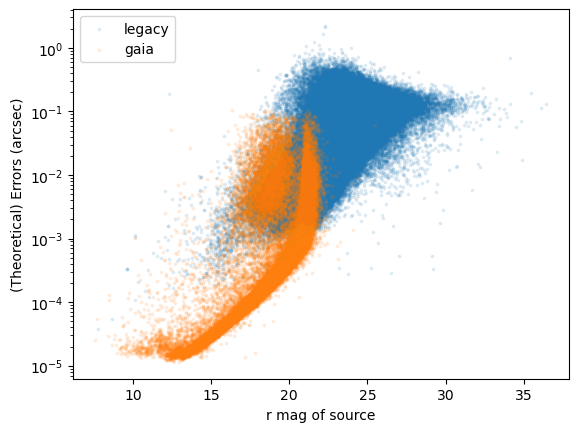

In [5]:
T.sigma_rd = np.hypot(np.sqrt(1/T.ra_ivar), np.sqrt(1/T.dec_ivar)) * 60**2 # units np.sqrt(1/deg^-2) * 60**2 = arcsec
T.mag = -2.5*(np.log10(T.flux_r) - 9)
NG = np.flatnonzero(T.ref_cat != 'GE')
plt.scatter(T.mag[NG], T.sigma_rd[NG], alpha=0.1, s=3, label='legacy')
G = np.flatnonzero(T.ref_cat == 'GE')
plt.scatter(T.mag[G], T.sigma_rd[G], alpha=0.1, s=3, label='gaia')

plt.ylabel('(Theoretical) Errors (arcsec)')
plt.xlabel('r mag of source');
# plt.ylim(0, 1)
plt.yscale('log')
plt.legend()

In [6]:
F.sigma_rd = np.sqrt(1. / F.full_fit_dra_ivar + 1. / F.full_fit_ddec_ivar)
F.err_rd_dcr = np.hypot(F.dcr_full_fit_dra, F.dcr_full_fit_ddec)
F.err_rd_rm = np.hypot(F.rm_full_fit_dra, F.rm_full_fit_ddec)
F.err_rd_lm = np.hypot(F.lm_full_fit_dra, F.lm_full_fit_ddec)
F.err_rd_before = np.hypot(F.full_fit_dra, F.full_fit_ddec)
F.mag = -2.5*(np.log10(F.flux) - 9)

objmap = dict([((bid,oid),i) for i,(bid,oid) in enumerate(zip(T.brickid, T.objid))])
F.t_index = np.array([objmap.get((bid,oid), -1) for bid,oid in zip(F.brickid, F.objid)])
F.sigma_rd = np.sqrt(1. / F.full_fit_dra_ivar + 1. / F.full_fit_ddec_ivar)
F.ref_cat = T.ref_cat[F.t_index]
F.pmra = T.pmra[F.t_index]

/tmp/ipykernel_664176/1355153231.py:1: RuntimeWarning: divide by zero encountered in divide
  F.sigma_rd = np.sqrt(1. / F.full_fit_dra_ivar + 1. / F.full_fit_ddec_ivar)
/tmp/ipykernel_664176/1355153231.py:6: RuntimeWarning: invalid value encountered in log10
  F.mag = -2.5*(np.log10(F.flux) - 9)
/tmp/ipykernel_664176/1355153231.py:10: RuntimeWarning: divide by zero encountered in divide
  F.sigma_rd = np.sqrt(1. / F.full_fit_dra_ivar + 1. / F.full_fit_ddec_ivar)


In [7]:
# F_corr.cut(F_corr.t_index > -1)
# F_corr.cut(F_corr.filter == 'g')
# F_corr.cut(F_corr.full_fit_dra_ivar > 0)
# F_corr.cut(F_corr.sigma_rd < 10)
# F_corr.cut(F_corr.fracin > 0.9)
# F_corr.cut(F_corr.x != 0)

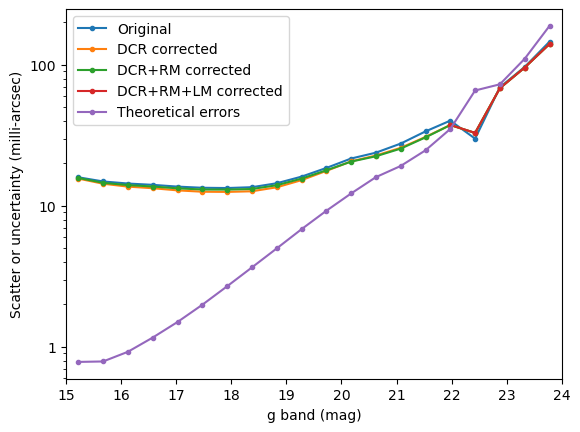

In [8]:
mags = np.linspace(15, 24, 21)
scat1 = []
scat2 = []
scat3 = []
scat4 = []
err = []
mm = []
for mlo,mhi in zip(mags, mags[1:]):
    I = np.flatnonzero((F.mag > mlo) * (F.mag <= mhi) * (F.ref_cat == 'GE'))
    scat1.append(np.median(F.err_rd_before[I]))
    scat2.append(np.median(F.err_rd_dcr[I]))
    scat3.append(np.median(F.err_rd_rm[I]))
    scat4.append(np.median(F.err_rd_lm[I]))
    err.append(np.median(F.sigma_rd[I]))
    mm.append((mlo+mhi)/2)
plt.semilogy(mm, 1000. * np.array(scat1), '.-', label='Original')
plt.semilogy(mm, 1000. * np.array(scat3), '.-', label='DCR corrected')
plt.semilogy(mm, 1000. * np.array(scat2), '.-', label='DCR+RM corrected')
plt.semilogy(mm, 1000. * np.array(scat4), '.-', label='DCR+RM+LM corrected')
plt.semilogy(mm, 1000. * np.array(err), '.-', label='Theoretical errors')
plt.ylabel('Scatter or uncertainty (milli-arcsec)');
plt.xlabel('g band (mag)');
plt.legend();
yt = [1,10,100]
plt.yticks(yt, ['%i'%i for i in yt])
plt.xlim(15, 24);

## Some data prep

In [9]:
crpixes = {'S1': (2151.2, 14826.0),
 'S2': (2151.2, 10566.67),
 'S3': (2151.2, 6307.333),
 'N1': (-103.2001, 14826.0),
 'N2': (-103.2001, 10566.67),
 'N3': (-103.2001, 6307.333),
 'S8': (4405.6, 12696.33),
 'S9': (4405.6, 8437.0),
 'S14': (6660.0, 12696.33),
 'S15': (6660.0, 8437.0),
 'S20': (8914.4, 10566.67),
 'S25': (11168.8, 8437.0),
 'N8': (-2357.6, 12696.33),
 'N9': (-2357.6, 8437.0),
 'N14': (-4612.0, 12696.33),
 'N15': (-4612.0, 8437.0),
 'N20': (-6866.4, 10566.67),
 'N25': (-9120.8, 8437.0),
 'S10': (4405.6, 4177.667),
 'S11': (4405.6, -81.66665),
 'S12': (4405.6, -4341.0),
 'S13': (4405.6, -8600.334),
 'S18': (6660.0, -4341.0),
 'S19': (6660.0, -8600.334),
 'S16': (6660.0, 4177.667),
 'S17': (6660.0, -81.66665),
 'S21': (8914.4, 6307.333),
 'S22': (8914.4, 2048.0),
 'S23': (8914.4, -2211.333),
 'S24': (8914.4, -6470.667),
 'S26': (11168.8, 4177.667),
 'S27': (11168.8, -81.66665),
 'S28': (11168.8, -4341.0),
 'S29': (13423.2, 6307.333),
 'S30': (13423.2, 2048.0),
 'S31': (13423.2, -2211.333),
 'N4': (-103.2001, 2048.0),
 'N5': (-103.2001, -2211.333),
 'N6': (-103.2001, -6470.667),
 'N7': (-103.2001, -10730.0),
 'S4': (2151.2, 2048.0),
 'S5': (2151.2, -2211.333),
 'S6': (2151.2, -6470.667),
 'S7': (2151.2, -10730.0),
 'N10': (-2357.6, 4177.667),
 'N11': (-2357.6, -81.66665),
 'N12': (-2357.6, -4341.0),
 'N13': (-2357.6, -8600.334),
 'N18': (-4612.0, -4341.0),
 'N19': (-4612.0, -8600.334),
 'N16': (-4612.0, 4177.667),
 'N17': (-4612.0, -81.66665),
 'N21': (-6866.4, 6307.333),
 'N22': (-6866.4, 2048.0),
 'N23': (-6866.4, -2211.333),
 'N24': (-6866.4, -6470.667),
 'N26': (-9120.8, 4177.667),
 'N27': (-9120.8, -81.66665),
 'N28': (-9120.8, -4341.0),
 'N29': (-11375.2, 6307.333),
 'N30': (-11375.2, 2048.0),
 'N31': (-11375.2, -2211.333),
 'FS1': (11168.8, -8600.334),
 'FS2': (13423.2, -6470.667),
 'FS3': (15677.6, -81.6666),
 'FS4': (15677.6, 2129.667),
 'FN1': (-9120.8, -8600.334),
 'FN2': (-11375.2, -6470.667),
 'FN3': (-13629.6, -81.6666),
 'FN4': (-13629.6, 2129.667)}

In [10]:
T.cut(T.ref_cat == 'GE')
T.cut((T.flux_g > 0) * (T.flux_i > 0))
objmap = dict([((bid,oid),i) for i,(bid,oid) in enumerate(zip(T.brickid, T.objid))])
F.t_index = np.array([objmap.get((bid,oid), -1) for bid,oid in zip(F.brickid, F.objid)])

# F.gaia_pmra = T.pmra[F.t_index]
# F.gaia_pmdec = T.pmdec[F.t_index]
# F.gaia_pmra_ivar = T.pmra_ivar[F.t_index]
# F.gaia_pmdec_ivar = T.pmdec_ivar[F.t_index]
F.gaia_g = T.gaia_phot_g_mean_mag[F.t_index]
F.gaia_bp = T.gaia_phot_bp_mean_mag[F.t_index]
F.gaia_rp = T.gaia_phot_rp_mean_mag[F.t_index]
F.flux_g = T.flux_g[F.t_index]
# F.flux_r = T.flux_r[F.t_index]
F.flux_i = T.flux_i[F.t_index]
# F.flux_z = T.flux_z[F.t_index]
T.color = -2.5 * (np.log10(T.flux_g / T.flux_i))
F.color = T.color[F.t_index]

p = np.array([crpixes[c] for c in F.ccdname])
F.fpx = F.rm_full_fit_x - p[:,0]
F.fpy = F.rm_full_fit_y - p[:,1]

ux = F.fpx / np.hypot(F.fpx, F.fpy)
uy = F.fpy / np.hypot(F.fpx, F.fpy)
F.dr = (F.rm_full_fit_x - F.x) * ux + (F.rm_full_fit_y - F.y) * uy

In [11]:
# Define cuts I1,I2,I3 for the three color bins.
filt = 'r'
Iok = np.flatnonzero(F.filter == filt)

# pcolors = np.percentile(T.color[F.t_index[Iok]], [1, 33, 66, 99])
pcolors = [0, 1, 2.3, 3.5] # TODO
I1 = np.flatnonzero((F.filter == filt) * (F.color > pcolors[0]) * (F.color < pcolors[1]))
I2 = np.flatnonzero((F.filter == filt) * (F.color > pcolors[1]) * (F.color < pcolors[2]))
I3 = np.flatnonzero((F.filter == filt) * (F.color > pcolors[2]) * (F.color < pcolors[3]))
len(I1), len(I2), len(I3)

(174701, 10676936, 95624)

# DCR plots

In [12]:
CCD_annotated = fits_table('/global/cfs/cdirs/cosmo/work/users/dstn/forced-motions-dr10/survey-ccds-decam-dr10-bprp-kd.fits')
BPRP_MAP = dict([((expnum, ccdname), bprp) for expnum,ccdname,bprp in zip(CCD_annotated.expnum, CCD_annotated.ccdname, CCD_annotated.ccdbprp)])

F.bprp = F.gaia_bp - F.gaia_rp
F.bprp_calib = np.array([BPRP_MAP[(e,c)] for e,c in zip(F.expnum, F.ccdname)])
F.gi_calib = -0.56 + 1.34 * F.bprp_calib
F.gi_color = -2.5 * (np.log10(F.flux_g / F.flux_i))
F.gi_rel = F.gi_color - F.gi_calib

In [13]:
I = np.flatnonzero((F.filter == 'r') *
                   (F.full_fit_dra_ivar != 0) *
                   (F.full_fit_x != F.x) *
                   (F.gaia_bp != 0.) *
                   (F.gaia_rp != 0.) *
                   (F.flux_g != 0) * 
                   (F.flux_i != 0) *
                   (F.dp1 != 0.))
len(I)

3929534

In [14]:
dx = F.full_fit_x - F.x
dy = F.full_fit_y - F.y
F.ha = brick_DCR.hour_angle(F.ra, F.mjd + 0.5 * F.exptime / (24 * 60 * 60))
_, F.parallactic = brick_DCR.parallactic(F.dec, F.ha)
F.dp1_before = dx * np.cos(F.parallactic) - dy * np.sin(F.parallactic)

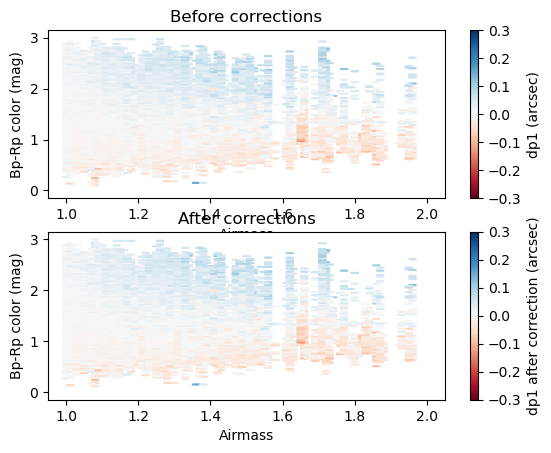

In [15]:
def my_reduce(x):
    if len(x) < 15:
        return np.nan
    return np.median(x)

plt.subplot(2, 1, 1)
plt.hexbin(F.airmass[I], F.bprp[I], C=F.dp1_before[I], reduce_C_function=my_reduce, vmin=-0.3, vmax=0.3,
          extent=(1.0, 2.0, 0., 3.0), gridsize=(50,100), cmap='RdBu');
plt.xlabel('Airmass')
plt.ylabel('Bp-Rp color (mag)')
plt.title("Before corrections")
cb = plt.colorbar()
cb.set_label('dp1 (arcsec)')

plt.subplot(2, 1, 2)
plt.hexbin(F.airmass[I], F.bprp[I], C=F.dp1[I], reduce_C_function=my_reduce, vmin=-0.3, vmax=0.3,
          extent=(1.0, 2.0, 0., 3.0), gridsize=(50,100), cmap='RdBu');
plt.xlabel('Airmass')
plt.ylabel('Bp-Rp color (mag)')
plt.title("After corrections")
cb = plt.colorbar()
cb.set_label('dp1 after correction (arcsec)')
plt.savefig('dcr-corr.png')

Text(0.5, 1.0, 'After corrections')

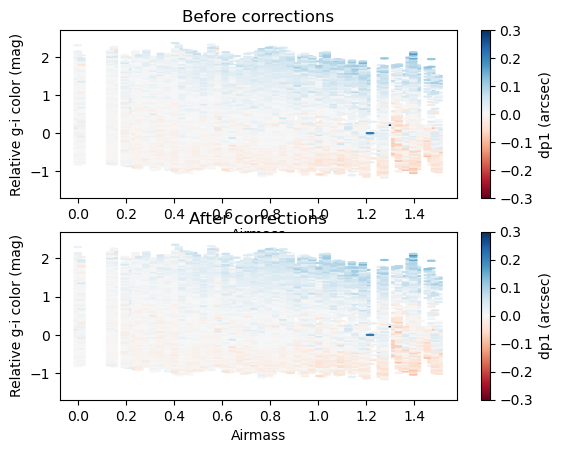

In [16]:
plt.subplot(2, 1, 1)
plt.hexbin(np.sqrt(F.airmass[I]**2 - 1), F.gi_rel[I], C=F.dp1_before[I], reduce_C_function=my_reduce, vmin=-0.3, vmax=0.3,
          extent=(0, 1.5, -1.5, 2.5), gridsize=(50,100), cmap='RdBu');
plt.xlabel('Airmass')
plt.ylabel('Relative g-i color (mag)')
cb = plt.colorbar()
cb.set_label('dp1 (arcsec)')
plt.title("Before corrections")

plt.subplot(2, 1, 2)
plt.hexbin(np.sqrt(F.airmass[I]**2 - 1), F.gi_rel[I], C=F.dp1[I], reduce_C_function=my_reduce, vmin=-0.3, vmax=0.3,
          extent=(0, 1.5, -1.5, 2.5), gridsize=(50,100), cmap='RdBu');
plt.xlabel('Airmass')
plt.ylabel('Relative g-i color (mag)')
cb = plt.colorbar()
cb.set_label('dp1 (arcsec)')
plt.title("After corrections")
# plt.savefig('dcr3.png')

# CCD distortions (tree rings + tape/screws) plots

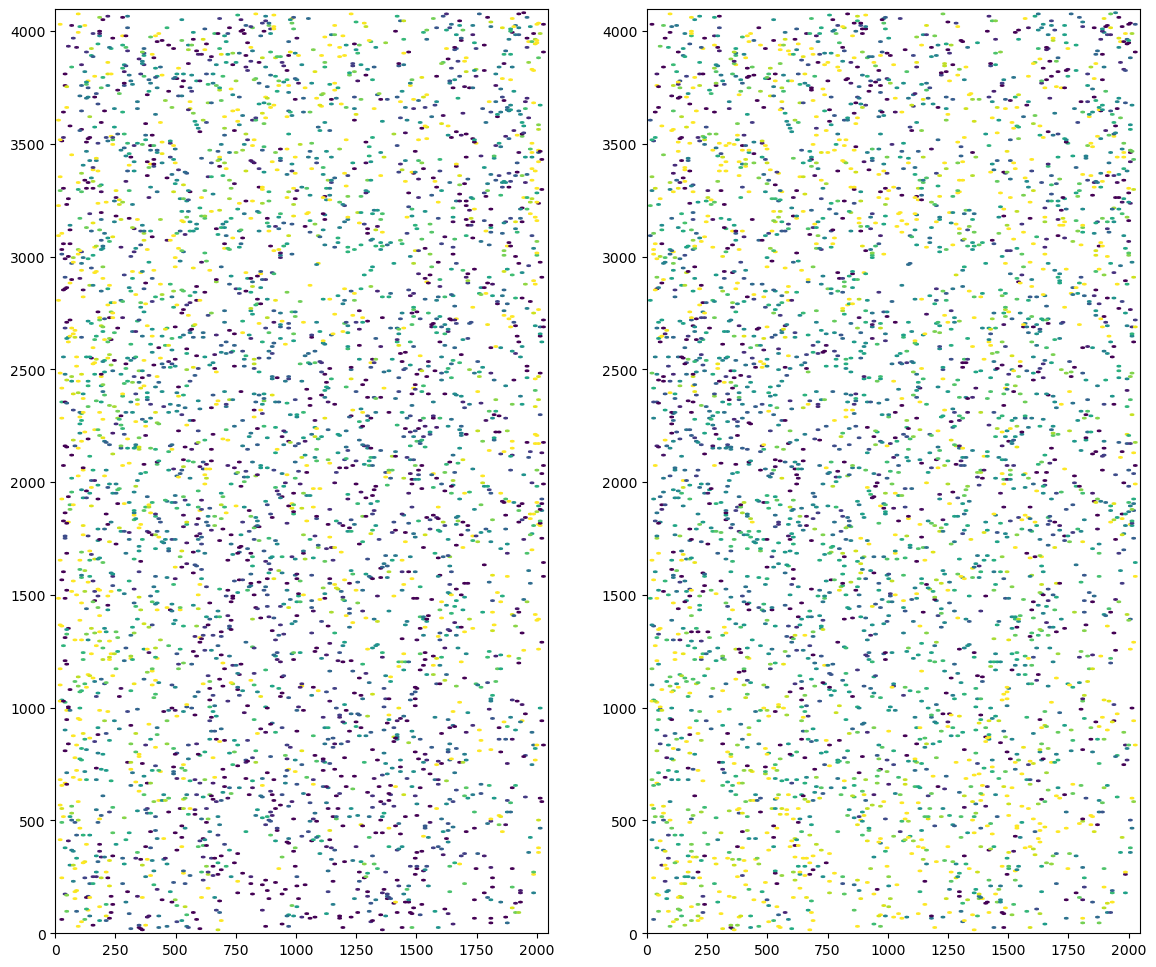

In [17]:
ccd = 'N4'
J = np.flatnonzero((F.ccdname == ccd)
                            * np.isin(F.filter, 'z')
                            * (F.full_fit_dra_ivar > 1e4)
                            * (F.full_fit_dra != 0.)
                            * (F.dqmask == 0))

plt.figure(figsize=(14,12))
ex = (0,2048,0,4096)
plt.subplot(1,2,1)
plt.hexbin(F.x[J], F.y[J], C=F.full_fit_x[J] - F.x[J], reduce_C_function=np.median, gridsize=(150,400),
           vmin=-0.05, vmax=+0.05, extent=ex);
plt.axis(ex);
plt.subplot(1,2,2)
plt.hexbin(F.x[J], F.y[J], C=F.full_fit_y[J] - F.y[J], reduce_C_function=np.median, gridsize=(150,400),
           vmin=-0.05, vmax=+0.05, extent=ex);
plt.axis(ex);

# Lateral plots

In [18]:
fpax = [F.fpx[Iok].min(), F.fpx[Iok].max(), F.fpy[Iok].min(), F.fpy[Iok].max()]

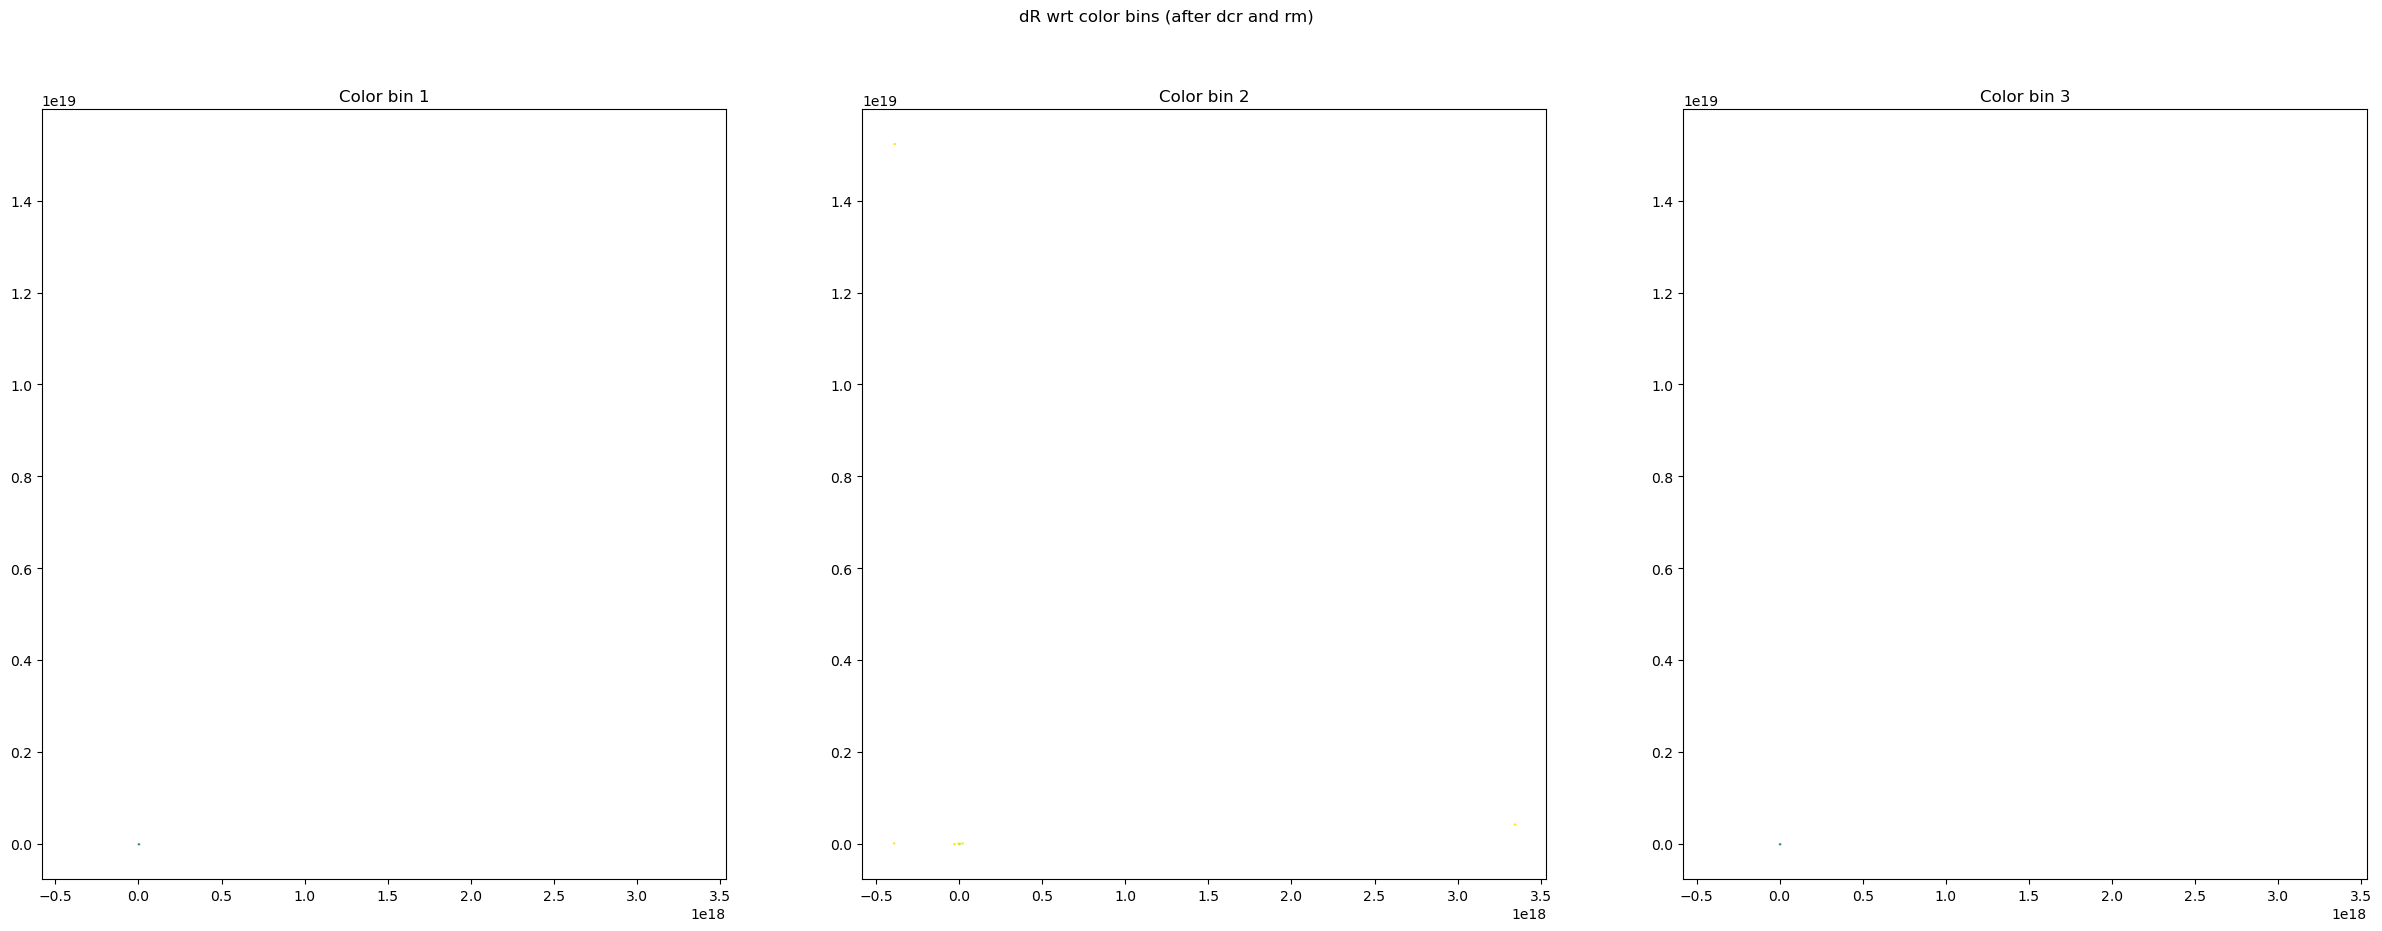

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(30, 10))
for i,I in enumerate([I1,I2,I3]):
    axes[i].hexbin(F.fpx[I], F.fpy[I], C=F.dr[I], reduce_C_function=np.median,
               gridsize=(500,500), vmin=-0.2, vmax=+0.2, extent=fpax, cmap='viridis')
    axes[i].set_title('Color bin %i' % (i+1))
plt.suptitle('dR wrt color bins (after dcr and rm)');

# Error Analysis

In [ ]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('py_files'), '..')))
from py_files import pm_analysis as pma
import numpy as np

# Loads every currently-valid tractor-pm-*.fits under the archive (corrupt/
# empty files -- see the pipeline-fix commit -- are skipped automatically).
# degrees=None (default) means this picks up more bricks with no code changes
# once Dustin regenerates the missing source data.
ARCHIVE = '/pscratch/sd/n/nelfalou/archive/legacypm-catalogue'
T, skipped = pma.load_catalogue(ARCHIVE, n_workers=16)
print(f"loaded {len(T)} rows, skipped {len(skipped)} corrupt/incomplete catalogue file(s)")


In [ ]:
# Uncertainty calibration check: (measured - Gaia truth) / formal_sigma should be
# ~unit Gaussian if the pmra_ivar/pmdec_ivar/parallax_new_ivar columns are
# correctly calibrated. Restricted to Gaia-reference PSF stars (the only ones
# with independent truth) with a genuinely successful fit -- see
# pma.gaia_star_mask for what "genuinely successful" filters out, including a
# sanity cut on |PM| (some fits are numerically degenerate but still
# "succeed" -- see the markdown note in the high-PM section below).
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model in zip(axes[:2], ['no_plx', 'plx']):
    mask = pma.gaia_star_mask(T, model=model)
    pull_ra, pull_dec, _ = pma.pm_pulls(T, mask, model=model)
    for pull, label in [(pull_ra, 'pmra'), (pull_dec, 'pmdec')]:
        stats = pma.robust_stats(pull)
        x = np.asarray(pull)
        x = x[np.isfinite(x) & (np.abs(x) < 10)]  # clip the display range; robust_stats already reports the true outlier rate
        ax.hist(x, bins=100, range=(-10, 10), histtype='step', density=True,
                label=f"{label}: median={stats['median']:.2f}, robust_sigma={stats['robust_sigma']:.2f}")
    xs = np.linspace(-10, 10, 200)
    ax.plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), 'k--', lw=1, label='unit Gaussian')
    ax.set_title(f"model={model}")
    ax.set_xlabel('pull = (measured - Gaia) / formal sigma')
    ax.legend(fontsize=8)

mask = pma.gaia_star_mask(T, model='plx')
_, _, pull_plx = pma.pm_pulls(T, mask, model='plx')
stats = pma.robust_stats(pull_plx)
x = np.asarray(pull_plx)
x = x[np.isfinite(x) & (np.abs(x) < 10)]
axes[2].hist(x, bins=100, range=(-10, 10), histtype='step', density=True,
             label=f"parallax: median={stats['median']:.2f}, robust_sigma={stats['robust_sigma']:.2f}")
xs = np.linspace(-10, 10, 200)
axes[2].plot(xs, np.exp(-xs**2/2)/np.sqrt(2*np.pi), 'k--', lw=1, label='unit Gaussian')
axes[2].set_title("parallax pull (plx model)")
axes[2].set_xlabel('pull = (measured - Gaia) / formal sigma')
axes[2].legend(fontsize=8)
plt.tight_layout()

# robust_sigma > 1 here means the ivar columns understate the true uncertainty
# by that factor -- as of this run it's ~1.5-1.7x for PM, ~1.3x for parallax.
# Worth a calibration factor (or re-deriving the +0.0148 arcsec / +0.005 arcsec
# error floors in the fitting code) before quoting these uncertainties in the paper.


# Proper motion comparisons

In [ ]:
# Full-sample PM/parallax vs Gaia truth, the "Proper motion comparisons" figure.
# Same success + sanity filtering as the pull-distribution cells above.
import matplotlib.pyplot as plt
import numpy as np

model = 'no_plx'
mask = pma.gaia_star_mask(T, model=model)
pmra = T.pmra_no_plx[mask]
pmdec = T.pmdec_no_plx[mask]
gaia_pmra = T.pmra[mask]
gaia_pmdec = T.pmdec[mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
lims = (-200, 200)
axes[0].scatter(gaia_pmra, pmra, s=1, alpha=0.05)
axes[0].plot(lims, lims, 'r-', lw=1, label='slope=1')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Gaia pmra (mas/yr)'); axes[0].set_ylabel('pipeline pmra_no_plx (mas/yr)')
axes[0].legend()

axes[1].scatter(gaia_pmdec, pmdec, s=1, alpha=0.05)
axes[1].plot(lims, lims, 'r-', lw=1, label='slope=1')
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('Gaia pmdec (mas/yr)'); axes[1].set_ylabel('pipeline pmdec_no_plx (mas/yr)')
axes[1].legend()
plt.tight_layout()


In [ ]:
# Precision vs magnitude -- only covers the Gaia-anchored range, since Gaia is
# the only source of ground truth here. Extending this to fainter, non-Gaia
# stars (where this survey's value-add actually is) needs a different
# ground-truth strategy (e.g. repeat-visit scatter) -- not implemented yet,
# see the markdown note below.
import matplotlib.pyplot as plt

mask = pma.gaia_star_mask(T, model='no_plx')
centers, med_ra, med_dec, counts = pma.precision_vs_magnitude(T, mask)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(centers, med_ra, '.-', label='median |resid_ra|')
ax.plot(centers, med_dec, '.-', label='median |resid_dec|')
ax.set_xlabel('Gaia G mag')
ax.set_ylabel('median |measured - Gaia PM| (mas/yr)')
ax.legend()
for c, n in zip(centers, counts):
    ax.annotate(str(n), (c, 0), xytext=(0, -15), textcoords='offset points',
                fontsize=7, ha='center', color='gray')
ax.set_title('Precision vs magnitude (annotations = star count per bin)')


# Footprint & data completeness

How many bricks in the archive are actually usable, per degree -- this
directly reflects the corrupt-file issue found and fixed this session
(zero-byte/truncated outputs from the old silent-exception-swallowing bug).
Only degrees 060-063 currently have any valid bricks; everything outside
that range needs Dustin's source data regenerated before it contributes
to the paper sample.

In [ ]:
import os, glob
import matplotlib.pyplot as plt

ARCHIVE = '/pscratch/sd/n/nelfalou/archive/legacypm-catalogue'
degrees = sorted(os.listdir(ARCHIVE))
good_counts, bad_counts = [], []
for deg in degrees:
    d = os.path.join(ARCHIVE, deg)
    files = sorted(glob.glob(os.path.join(d, "tractor-pm-*.fits")))
    good = sum(1 for f in files if os.path.getsize(f) > 0)
    good_counts.append(good)
    bad_counts.append(len(files) - good)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(degrees))
ax.bar(x, good_counts, label='valid', color='C0')
ax.bar(x, bad_counts, bottom=good_counts, label='corrupt/empty', color='C3')
ax.set_xticks(x); ax.set_xticklabels(degrees, rotation=90)
ax.set_ylabel('bricks')
ax.legend()
ax.set_title(f"total valid: {sum(good_counts)}, total corrupt: {sum(bad_counts)}")
plt.tight_layout()


# High proper-motion / non-Gaia discovery candidates -- BLOCKED

This is the "payoff" figure for the paper (objects with real, usable PM that
Gaia doesn't measure well or at all) -- but it isn't trustworthy yet.

A first-pass search (`pma.non_gaia_psf_mask` + a sanity cutoff of
|PM| < 10,000 mas/yr, already faster than any known real star) still returned
tens of thousands of "candidates" that pile up suspiciously just under
whatever cutoff is chosen, rather than tapering off naturally. That's a sign
the numerical instability in the least-squares fit (`pm_lsq`/`pm_lsq_plx` in
`create_brick_catalogue.py` -- likely from stars with few or time-clustered
epochs giving an ill-conditioned design matrix) contaminates the PM
distribution well below any simple magnitude ceiling, not just as rare
extreme outliers.

Before this section can produce a real candidate list, the fitting code needs
a proper fit-quality diagnostic -- e.g. a minimum epoch count, a minimum time
baseline, or a condition-number check on `A.T @ A` in `pm_lsq`/`pm_lsq_plx`,
flagging (or refusing) fits that don't meet it. That's a fit-methodology
decision, not a bug fix, so it needs your call on the right threshold(s)
before implementing.